In [2]:
import sys
import os
import time

from SelfCal import PipelineWrapper
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, \
load_calibration, make_spherex_offset_map, compute_offsets_guess, load_lvf_params, compute_vertical_strip_adjacency, \
make_stripped_chunk_map, make_stripped_chunk_valid_mask, make_spherex_stripped_offset_map
from SelfCal.SPHERExAppendWav import wav_coadd

from astropy.io import fits
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
mpl.rcParams['figure.dpi'] = 200
# Import LogNorm
from tqdm import tqdm
import gc
from functools import partial


In [5]:
from tqdm import tqdm
from SelfCal.MakeMap import load_reproj_file
old_reproj_list = sorted(glob.glob('/mnt/md124/caoye/selfcal/outputs/nep_det2_6p2arcsec/old_reprojected/*.h5'))
new_reproj_list = sorted(glob.glob('/mnt/md124/caoye/selfcal/outputs/nep_det2_6p2arcsec/reprojected/*.h5'))

import h5py

new_p = new_reproj_list[0]
with h5py.File(new_p, 'r') as f:
    print(f.keys())
    print(f.attrs.keys())
    sub_data = f['sub_data'][:]

old_p = old_reproj_list[0]
with h5py.File(old_p, 'r') as f:
    print(f.keys())
    sub_data_old = f['sub_data'][:]

# for old_p, new_p in tqdm(zip(old_reproj_list[:], new_reproj_list[:]), total=len(old_reproj_list)):
#     with h5py.File(old_p, 'r') as f_source:
#         sub_data = f_source['sub_data'][:]
    
#     with h5py.File(new_p, 'r+') as f_target:
#         if 'sub_data' in f_target:
#             f_target['sub_data'][:] = sub_data
#         else:
#             f_target.create_dataset('sub_data', data=sub_data)

<KeysViewHDF5 ['sub_bitmask', 'sub_data', 'sub_foot', 'sub_mapping']>
<KeysViewHDF5 ['det_header', 'file_path', 'ref_coords', 'sub_header']>
<KeysViewHDF5 ['det_data', 'det_header', 'file_path', 'grid_bitmask', 'grid_mapping', 'ref_coords', 'sub_data', 'sub_foot', 'sub_header']>


In [2]:
def prepare_detector_inputs(frame_setting, calibration_setting, mosaic_setting):
    detector = frame_setting['Detector']
    num_subchannels = frame_setting['NumSub']
    num_channels = frame_setting['NumCh']
    num_columns = frame_setting['NumCol']
    oversample_factor = mosaic_setting['OversampleFactor']

    lvf_filename = f'lvf_params_D{detector}.npy'
    lvf_params = load_lvf_params(lvf_filename)

    det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
    grid_chunk_map, _, _, _ = make_stripped_chunk_map(detector, num_subchannels=num_subchannels, num_channels=num_channels, num_columns=num_columns,
                                                    oversample_factor=oversample_factor, lvf_params=lvf_params)
    det_chunk_map, _, r_edges, x_edges = make_stripped_chunk_map(detector, num_subchannels=num_subchannels, num_channels=num_channels, num_columns=num_columns,
                                            oversample_factor=1, lvf_params=lvf_params)
    detector_inputs = {
        'lvf_params': lvf_params,
        'det_BC': det_BC,
        'det_BW': det_BW,
        'grid_chunk_map': grid_chunk_map,
        'det_chunk_map': det_chunk_map,
        'r_edges': r_edges,
        'x_edges': x_edges
    }
    return detector_inputs

def prepare_channel_inputs(ch, frame_setting):
    num_subchannels = frame_setting['NumSub']
    num_channels = frame_setting['NumCh']
    num_columns = frame_setting['NumCol']
     # Prepare masks
    chunk_valid_mask_padded = make_stripped_chunk_valid_mask(ch, num_subchannels=num_subchannels, num_channels=num_channels, 
                                        num_columns=num_columns, subchannel_padding=1)
    chunk_valid_mask = make_stripped_chunk_valid_mask(ch, num_subchannels=num_subchannels, num_channels=num_channels, 
                                        num_columns=num_columns, subchannel_padding=0)

    channel_inputs = {
        'chunk_valid_mask_padded': chunk_valid_mask_padded,
        'chunk_valid_mask': chunk_valid_mask
    }
    return channel_inputs

In [3]:
frame_setting = {
    'Detector': 2,
    'NumSub': 10,
    'NumCh': 17,
    'NumCol': 2,
}

calibration_setting = {
    'ApplyMask': True,
    'ApplyWeight': False,
    'OutlierThresh': 2.0,
    'IgnoreList': [],
    'OffsetRegularization': True,
    'RegWeight': 10.0,
    'WeightedDamping': True,
    'DampWeight': 10.0,
}

mosaic_setting = {
    'ApplyMask': True,
    'ApplyWeight': False,
    'MakeStdMap': True,
    'ApplySigmaClipping': True,
    'Sigma': 1.0,
    'IgnoreList': [21],
    'OversampleFactor': 2,
}

CACHE_DIR = '/home/thomasli/spherex/selfcal/cache/'
FILE_SUFFIX = f''

selfcal_config = {}
selfcal_config['output_dir'] = '/mnt/md124/caoye/selfcal/outputs/'
selfcal_config['run_name'] = f'nep_det2_6p2arcsec'
selfcal_config['resolution_arcsec'] = 6.2

In [4]:
frame_setting_str = '_'.join([f'{key}{value}' for key, value in frame_setting.items()])
detector_inputs = prepare_detector_inputs(frame_setting, calibration_setting, mosaic_setting)
chs = [[4]]
channel_jobs = {
    f'Ch{"-".join(map(str, ch))}': prepare_channel_inputs(ch, frame_setting) for ch in chs
    }
job_name, channel_inputs = list(channel_jobs.items())[0]

Loaded LVF parameters from /home/thomasli/spherex/selfcal/selfcal_scripts/lvf_params/lvf_params_D2.npy


  5%|██████▏                                                                                                              | 9/171 [00:00<00:05, 28.41it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:01<00:00, 132.61it/s]


In [5]:
chunk_valid_mask_padded = channel_inputs['chunk_valid_mask_padded']
chunk_valid_mask = channel_inputs['chunk_valid_mask']
adj_info = compute_vertical_strip_adjacency(detector_inputs['det_chunk_map'], frame_setting['NumCol'])
job_tag = f'D{frame_setting["Detector"]}_{job_name}_{frame_setting_str}'
cal_file = f'cal_{job_tag}{FILE_SUFFIX}.h5'
mos_file = f"mosaic_{job_tag}{FILE_SUFFIX}.fits"


Computing Vertical Strip Adjacency (Filtering Arcs)...
Found 171 vertical strip boundaries.


In [6]:
cc = PipelineWrapper.Calibrator(selfcal_config)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3288/3288 [00:00<00:00, 784508.31it/s]

Loading reference frame from: /mnt/md124/caoye/selfcal/outputs/nep_det2_6p2arcsec/ref.fits


In [7]:
import importlib
importlib.reload(PipelineWrapper)

<module 'SelfCal.PipelineWrapper' from '/home/thomasli/spherex/selfcal/SelfCal/PipelineWrapper.py'>

In [ ]:
cc = PipelineWrapper.Calibrator(selfcal_config)
cc.setup_lsqr(
    apply_mask=False, 
    apply_weight=False,
    chunk_map=detector_inputs['det_chunk_map'], 
    grid_valid_weight=chunk_valid_mask_padded[detector_inputs['det_chunk_map']], 
    max_workers=50, 
    outlier_thresh=calibration_setting['OutlierThresh'],
    ignore_list=calibration_setting['IgnoreList'],
    oversample_factor=1,
    batch_size=30,
    offset_regularization=calibration_setting['OffsetRegularization'],
    reg_weight=calibration_setting['RegWeight'],
    adj_info=adj_info,
    weighted_damping=calibration_setting['WeightedDamping'],
    damp_weight=calibration_setting['DampWeight'],
    )

cc.apply_lsqr(x0=None, atol=1e-06, btol=1e-06, damp=1e-3, iter_lim=100, precondition=False)

cal_path = cc.save_calibration(cal_file=cal_file)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3288/3288 [00:00<00:00, 566127.73it/s]

Loading reference frame from: /mnt/md124/caoye/selfcal/outputs/nep_det2_6p2arcsec/ref.fits
Processing 3288 items in 110 batches...


Building A, b matrix: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 110/110 [03:22<00:00,  1.84s/it]


Applying Coverage-Weighted Damping...
LSQR setup completed in 416.48 seconds.
Solving least squares for 69257040 unknowns with 779709837 equations.
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 779709837 rows and 69257040 columns
damp = 1.00000000000000e-03   calc_var =        0
atol = 1.00e-06                 conlim = 1.00e+08
btol = 1.00e-06               iter_lim =      100
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   7.650e+03  7.650e+03    1.0e+00  1.3e-02
     1  0.00000e+00   5.146e+02  5.146e+02    6.7e-02  8.5e-01   9.7e+01  1.0e+00
     2  0.00000e+00   2.563e+02  2.563e+02    3.4e-02  1.7e-01   1.4e+02  2.0e+00
     3  0.00000e+00   2.469e+02  2.469e+02    3.2e-02  8.2e-02   1.6e+02  3.0e+00
     4  0.00000e+00   2.398e+02  2.398e+02    3.1e-02  9.4e-02   1.8e+02  4.9e+00
     5  0.00000e+00   2.305e+02  2.305e+02    3.0e-02  7.7e-02   2.0e+02  8.0e+00
     6  0.00000e+00   2.228e+02  2.228e+0

In [10]:
partial_make_offset_map = partial(make_spherex_stripped_offset_map,
                            chunk_valid_mask=chunk_valid_mask, 
                            lvf_params=detector_inputs['lvf_params'], 
                            r_edges=detector_inputs['r_edges'], 
                            x_edges=detector_inputs['x_edges'], 
                            tot_subchannels=frame_setting['NumSub']*frame_setting['NumCh']+2, 
                            num_columns=frame_setting['NumCol'])

mm = PipelineWrapper.Mosaicker(selfcal_config)
mm.load_calibration(cal_path=cal_path)
cache_dir = f'{CACHE_DIR}cache_{job_tag}'
maps = mm.make_mosaic(
    apply_mask=mosaic_setting['ApplyMask'], 
    apply_weight=mosaic_setting['ApplyWeight'], 
    chunk_map=detector_inputs['grid_chunk_map'], 
    grid_valid_weight=chunk_valid_mask[detector_inputs['grid_chunk_map']], 
    max_workers=50,
    make_std_map=mosaic_setting['MakeStdMap'], 
    apply_sigma_clipping=mosaic_setting['ApplySigmaClipping'],  
    sigma=mosaic_setting['Sigma'],
    ignore_list=mosaic_setting['IgnoreList'],
    oversample_factor=mosaic_setting['OversampleFactor'],
    det_offset_func=partial_make_offset_map,#partial_make_offset_map,
    cache_batch_size=40,
    coadd_batch_size=100,
    cache_dir=cache_dir,
    cache_intermediate=True,
    det_aux=None
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3288/3288 [00:00<00:00, 467931.31it/s]

Loading reference frame from: /mnt/md124/caoye/selfcal/outputs/nep_det2_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/caoye/selfcal/outputs/nep_det2_6p2arcsec/calibration/cal_D2_Ch4_Detector2_NumSub10_NumCh17_NumCol2.h5
Caching intermediate computations...
Processing 3288 files in 83 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 83/83 [11:23<00:00,  8.23s/it]


Cache computation finished in 712.95 seconds.
Computing mean map...
Processing 3288 files in 33 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [02:10<00:00,  3.95s/it]


Mean map computation finished in 164.14 seconds.
Computing std map...
Processing 3288 files in 33 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [02:31<00:00,  4.59s/it]


Std map computation finished in 187.03 seconds.
Computing sigma-clipped mean map...
Processing 3288 files in 33 batches...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [01:41<00:00,  3.06s/it]


Sigma-clipped mean map computation finished in 128.72 seconds.


In [124]:
import importlib
import SelfCal.SPHERExUtility
import SelfCal.MapHelper
importlib.reload(SelfCal.SPHERExUtility)
importlib.reload(SelfCal.MapHelper)
from SelfCal.SPHERExUtility import *
from SelfCal.MapHelper import *

In [11]:
mosaic = mm.maps['mean_map']['data']
weight = mm.maps['mean_map']['weight']
masked_mosaic = np.where(weight <= 0, np.nan, mosaic)

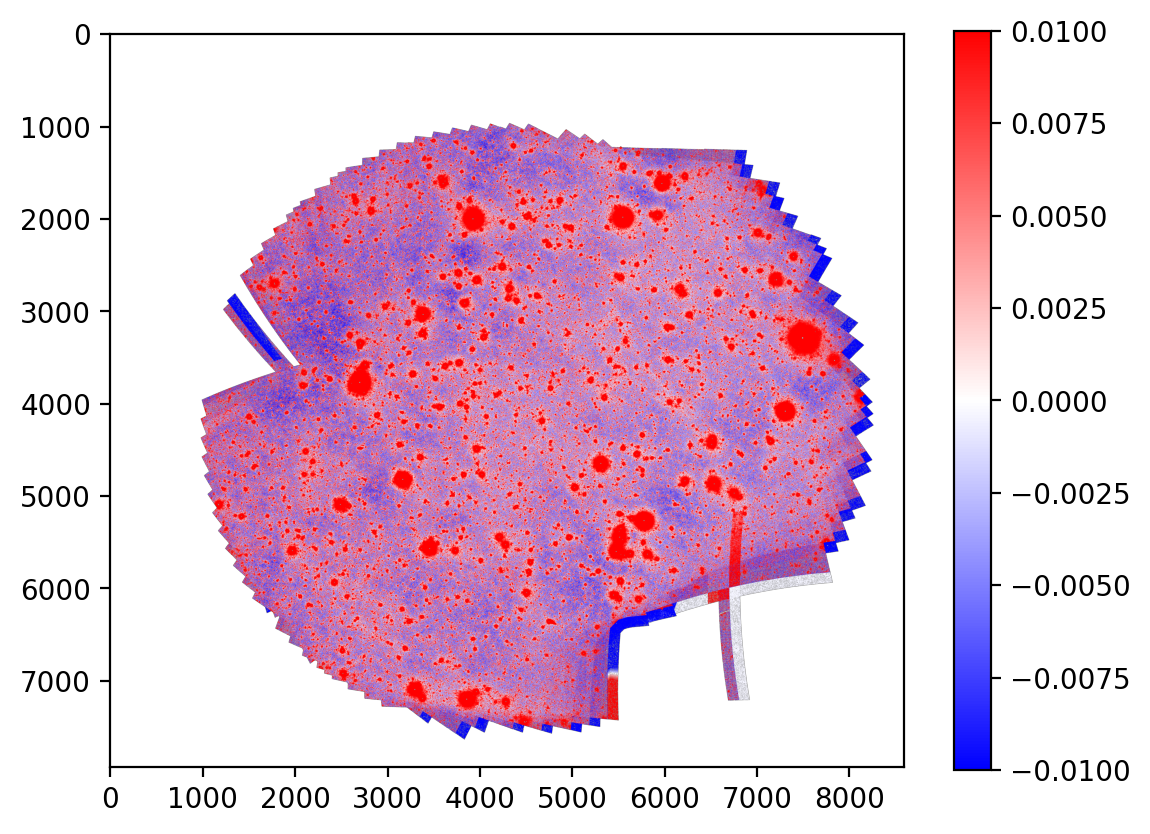

In [12]:
plt.imshow(masked_mosaic-np.nanmedian(masked_mosaic), vmin=-0.01, vmax=0.01, cmap='bwr')
plt.colorbar()